In [1]:
import sys
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from scipy import stats

DIR_PARENT = Path().cwd()
DIR_RESULTS = DIR_PARENT.parents[1] / "results"
DIR_OUT = DIR_RESULTS / "empirical_complexity_plots"

# sys.path.insert(0, str(DIR_PARENT))
# from plot_empirical_complexity import (
#     plot_data_size_vs_time,
# )

ESTIMATOR_RENAMING = {
    "bxt_bgso_kronrls": "Oxytree",
    "bxt_bgso": "Oxytree[Deep]",
    "bxt_gmo": "BICTR",
}
PATH_FIT_RESULTS = DIR_RESULTS / "empirical_complexity_fit.csv"
PATH_PREDICT_RESULTS = DIR_RESULTS / "empirical_complexity_predict.csv"

def set_rc_params():
    plt.rcParams.update(
        {
            "text.usetex": True,
            "font.family": "serif",
            # "font.size": 12,
            # "axes.titlesize": 12,
            # "axes.labelsize": 12,
            # "xtick.labelsize": 12,
            # "ytick.labelsize": 12,
            "legend.fontsize": 6,
            # "figure.titlesize": 12,
        }
    )


In [2]:
def format_p_value(p, alpha=0.05):
    if p > alpha:
        return f"p \\approx {p:.2g}"

    n_decimals = int(np.ceil(-np.log10(p)))
    pvalue_noexp = int(np.ceil(p * 10**n_decimals))

    if n_decimals == 1:
        return f"p < 0.{pvalue_noexp:.0f}"
    if pvalue_noexp == 10:
        short_pvalue_str = f"10^{{-{n_decimals - 1}}}"
    elif pvalue_noexp == 1:
        short_pvalue_str = f"10^{{-{n_decimals}}}"
    else:
        short_pvalue_str = f"{pvalue_noexp} \\cdot 10^{{-{n_decimals}}}"
    pvalue_eq = f"p < {short_pvalue_str}"
    return pvalue_eq

In [3]:
sns.set_context("notebook")
plt.rcParams.update(
    {
        "font.family": "Times New Roman",
        "figure.dpi": 300,
    }
)
fit_data = pd.read_csv(PATH_FIT_RESULTS)
fit_data["estimator"] = fit_data["estimator"].map(ESTIMATOR_RENAMING)
predict_data = pd.read_csv(PATH_PREDICT_RESULTS)

# plot_empirical_complexity_fit(data=fit_data, outdir=outdir)
# plot_empirical_complexity_predict(data=predict_data, outdir=outdir)
# Ensure same log base
predict_data["log_data_size"] = np.log10(predict_data["data_size"])
predict_data["log_predict_time"] = np.log10(predict_data["predict_time"])
predict_data["log_predict_time_single"] = np.log10(predict_data["predict_time_single"])

# Convert to seconds
predict_data[["predict_time", "predict_time_single", "fit_time"]] /= 1e9

# Convert to hours
fit_data[["predict_time", "predict_time_single", "fit_time"]] /= 1e9  * 60 * 60

# Convert to dumber of dyads
# fit_data["data_size"] **= 2
# predict_data["data_size"] **= 2

In [4]:
fit_data

,estimator,data_size,iteration,predict_time_single,predict_time,fit_time
0,BICTR,10,0,NaN,2.463539e-07,0.000001
1,NaN,10,0,NaN,2.736594e-07,0.000001
2,Oxytree[Deep],12,2,2.718750e-07,2.653472e-07,0.000001
3,Oxytree[Deep],10,0,2.542389e-07,2.669003e-07,0.000001
4,BICTR,12,2,NaN,2.603319e-07,0.000001
...,...,...,...,...,...,...
465,Oxytree,7897,70,NaN,8.250536e-04,1.889776
466,NaN,7897,70,NaN,8.148204e-04,1.855519
467,NaN,8687,71,NaN,7.998105e-04,2.102488
468,Oxytree,8687,71,NaN,8.938173e-04,1.850745


In [5]:
def plot_data_size_vs_time(
    *,
    data: pd.DataFrame,
    reg_data: pd.DataFrame,
    data_size_col: str,
    time_col: str,
    group_col: str,
    ylabel: str = "Training time (minutes)",
    xlabel: str = "Data size",
):
    # plt.subplots(1, 3, figsize=(18, 4))

    # plt.subplot(1, 3, 1)
    plt.figure(1, figsize=(4, 3))
    plt.grid(axis="y")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # plt.subplot(1, 3, 2)
    plt.figure(2, figsize=(4, 3))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xscale("log")
    plt.yscale("log")

    # plt.subplot(1, 3, 3)
    plt.figure(3, figsize=(4, 3))
    plt.xlabel(xlabel)
    plt.ylabel("Residuals")
    plt.xscale("log")
    # plt.yscale("log")

    for i, (estimator, estimator_data) in enumerate(data.groupby(group_col)):
        # plt.subplot(1, 3, 1)
        plt.figure(1)
        plt.scatter(
            estimator_data[data_size_col],
            estimator_data[time_col],
            label=estimator,
            marker="|",
            color=f"C{i}",
        )

        # plt.subplot(1, 3, 2)
        plt.figure(2)
        plot = plt.scatter(
            estimator_data[data_size_col],
            estimator_data[time_col],
            marker="|",
            color=f"C{i}",
        )

    # plt.subplot(1, 3, 2)
    plt.figure(2)
    xlim = plt.xlim()
    ylim = plt.ylim()

    for i, (group_name, group_data) in enumerate(reg_data.groupby(group_col)):
        reg_data = group_data.loc[:, [data_size_col, time_col]].dropna()
        lr = stats.linregress(
            np.log2(reg_data[data_size_col]).values,
            np.log2(reg_data[time_col]).values,
        )
        x = np.linspace(xlim[0], xlim[1], 5)

        # plt.subplot(1, 3, 2)
        plt.figure(2)
        plt.plot(
            x,
            x**lr.slope * 2**lr.intercept,
            "-",
            color=f"C{i}",
            label=f"{group_name} (${lr.slope:.3g} \\pm {lr.stderr:.2g}$)",
        )

        residuals = (
            reg_data[time_col] - reg_data[data_size_col] ** lr.slope * 2**lr.intercept
        )
        residual_bins = [np.mean(a) for a in np.array_split(residuals, 20)]
        bin_positions = [
            np.mean(a) for a in np.array_split(reg_data[data_size_col], 20)
        ]

        # plt.subplot(1, 3, 3)
        plt.figure(3)
        plt.plot(
            # reg_data[data_size_col],
            # residuals,
            bin_positions,
            residual_bins,
            # np.log2(np.abs(residuals) * 100 + 1) * np.sign(residuals),
            "|",
            color=f"C{i}",
            label=group_name,
        )

    # plt.subplot(1, 3, 2)
    plt.figure(2)
    plt.xlim(xlim)
    plt.ylim(ylim)

    plt.legend(loc="upper left", framealpha=1)

In [6]:
def plot_empirical_complexity_predict(*, data: pd.DataFrame, outdir: Path):
    predict_time_cutoff = 4000
    predict_time_single_cutoff = 400
    renaming = {
        "predict_time": "Oxytree (batch)",
        "predict_time_single": "PBCT (individual)",
    }

    data = data.copy()

    # Convert nanoseconds to minutes
    data.loc[:, ["predict_time", "predict_time_single"]] /= 60e9

    predict_data = data.loc[:, ["data_size", "predict_time", "predict_time_single"]]
    predict_data = predict_data.melt(
        id_vars="data_size",
        value_vars=["predict_time", "predict_time_single"],
        var_name="predict_function",
    )
    predict_data = predict_data.sort_values("predict_function")

    # Apply cuttoffs to the data
    reg_data = predict_data.loc[
        (
            (predict_data.predict_function == "predict_time")
            & (predict_data.data_size > predict_time_cutoff)
        )
        | (
            (predict_data.predict_function == "predict_time_single")
            & (predict_data.data_size > predict_time_single_cutoff)
        )
    ]

    # Rename the predict function
    predict_data.loc[:, "predict_function"] = predict_data.predict_function.replace(
        renaming
    )
    reg_data.loc[:, "predict_function"] = reg_data.predict_function.replace(renaming)

    plot_data_size_vs_time(
        data=predict_data,
        reg_data=reg_data,
        data_size_col="data_size",
        time_col="value",
        group_col="predict_function",
        xlabel="Number of instances in each dimension",
        ylabel="Prediction time (minutes)",
    )

    # Possible because of sorting
    plt.axvline(predict_time_cutoff, color="C0", linestyle="--")
    plt.axvline(predict_time_single_cutoff, color="C1", linestyle="--")

    outdir.mkdir(parents=True, exist_ok=True)
    base_out = outdir / "predicting_empirical_complexity"

    for i in range(1, 4):
        out = base_out.with_stem(f"{base_out.stem}_{i}")
        plt.figure(i)
        plt.show()
        # plt.savefig(out.with_suffix(".png"), dpi=300, bbox_inches="tight")
        # plt.savefig(
        #     out.with_suffix(".pdf"),
        #     bbox_inches="tight",
        #     transparent=True,
        #     pad_inches=0.02,
        # )
        plt.clf()



In [7]:
predict_data_molten = (
    predict_data.melt(
        id_vars=["data_size"],
        value_vars=["predict_time", "predict_time_single"],
        var_name="predict_function",
    )
)

In [8]:
def plot_function(func, ax=None, n=100, kwargs=None):
    ax = ax or plt.gca()
    kwargs = kwargs or {}

    xlim = ax.get_xlim()
    x = np.linspace(xlim[0], xlim[1], n)
    y = func(x)

    autoscale = ax.get_autoscale_on()
    ax.autoscale(enable=False)
    plt.plot(x, y, **kwargs)
    ax.autoscale(enable=autoscale)

    return ax


def plot_empirical_complexity_log(
    data: pd.DataFrame,
    x: str,
    y: str,
    last: int | float = 100,
    ax: plt.Axes | None = None,
    scatter_kwargs: dict | None = None,
    line_kwargs: dict | None = None,
):
    scatter_kwargs = scatter_kwargs or {}
    line_kwargs = line_kwargs or dict(
        label=f"{y} ({linreg.slope:.3g} $\\pm$ {linreg.stderr:.2g})",
    )
    ax = ax or plt.gca()

    data_view_var = data.copy().dropna(subset=y)

    if isinstance(last, int):
        # Select the last `last` entries
        size_cutoff = data_view_var.data_size.sort_values().iloc[-last]
    else:
        size_cutoff = data_view_var.data_size.quantile(last)

    selected_data = data_view_var.loc[data_view_var.data_size > size_cutoff, [x, y]]
    linreg = stats.linregress(*selected_data.values.T, alternative="greater")

    ax = sns.scatterplot(
        data=selected_data,
        ax=ax,
        x=x,
        y=y,
        # hue="predict_function",
        # logx=True,
        **scatter_kwargs,
    )

    x0 = np.mean(plt.xlim())

    plt.axline(
        (x0, linreg.slope * x0 + linreg.intercept),
        slope=linreg.slope,
        **line_kwargs,
    )

    return ax, linreg


def plot_empirical_complexity_linear(
    data: pd.DataFrame,
    x: str,
    y: str,
    linreg: None = None,
    ax: plt.Axes | None = None,
    scatter_kwargs: dict | None = None,
    line_kwargs: dict | None = None,
):
    scatter_kwargs = scatter_kwargs or {}
    line_kwargs = line_kwargs or {}
    ax = ax or plt.gca()

    data = data.copy().dropna(subset=y)

    ax = sns.scatterplot(
        ax=ax,
        data=data,
        x=x,
        y=y,
        # hue="predict_function",
        # logx=True,
        **scatter_kwargs,
    )

    if linreg is not None:
        plot_function(
            lambda xx: 10**linreg.intercept * xx**linreg.slope,
            kwargs=line_kwargs,
        )

    return ax

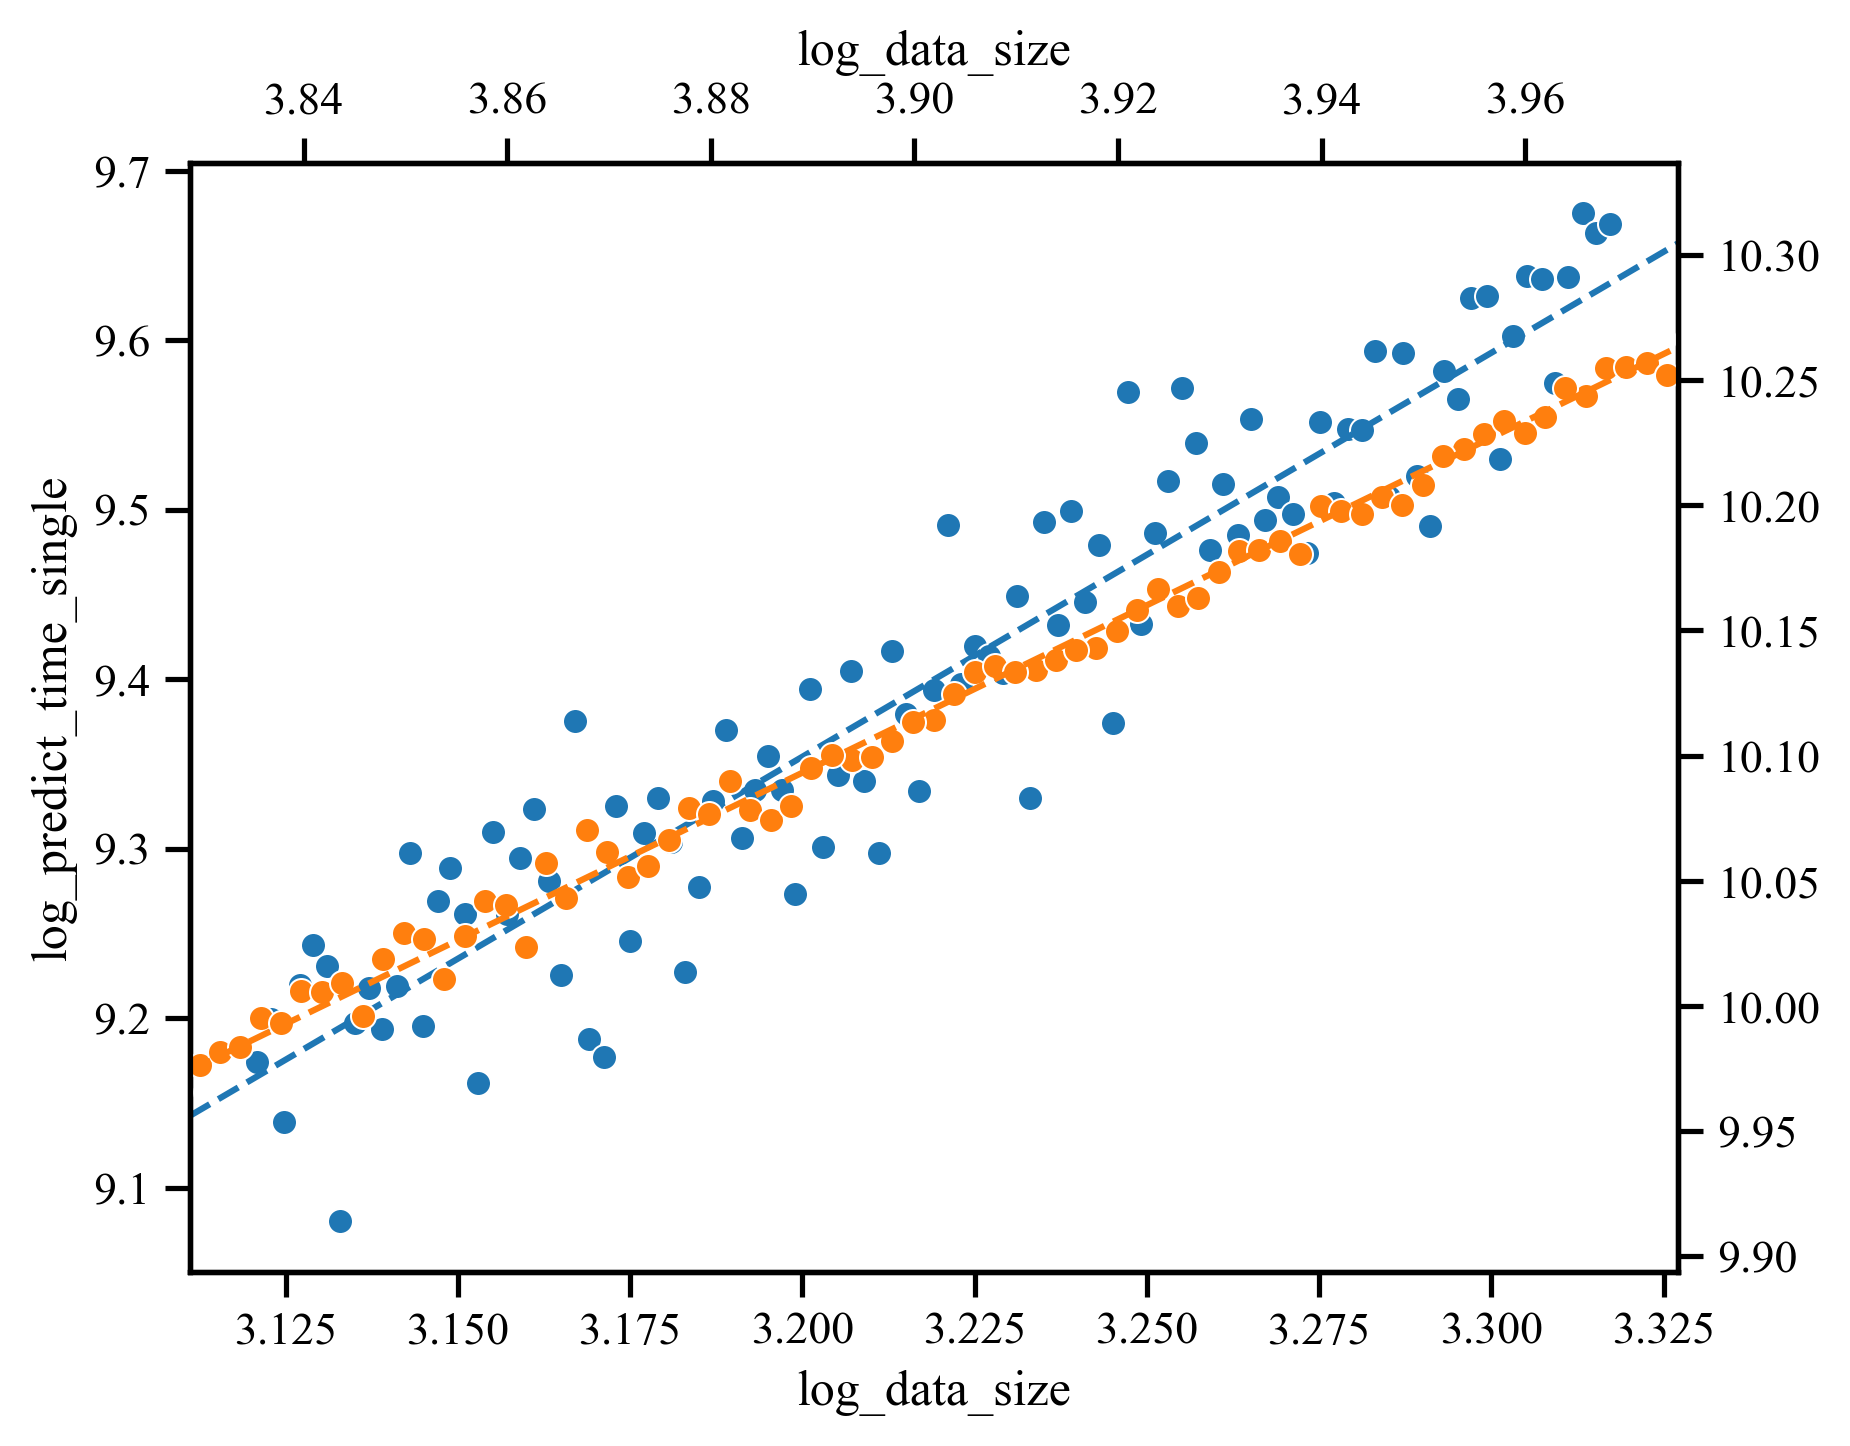

<Figure size 1920x1440 with 0 Axes>

In [9]:
last = 100
data_view = predict_data.copy()

plt.figure()

ax, linreg_single = plot_empirical_complexity_log(
    data=data_view,
    x="log_data_size",
    y="log_predict_time_single",
    last=last,
    scatter_kwargs=dict(
        marker="o",
        color="C0",
    ),
    line_kwargs=dict(
        linestyle="--",
        color="C0",
    ),
)

aspect_ratio = np.diff(ax.get_xlim()) / np.diff(ax.get_ylim())

ax2 = ax.twinx().twiny()

ax2, linreg = plot_empirical_complexity_log(
    data=data_view,
    x="log_data_size",
    y="log_predict_time",
    ax=ax2,
    last=last,
    scatter_kwargs=dict(
        marker="o",
        color="C1",
    ),
    line_kwargs=dict(
        linestyle="--",
        color="C1",
    ),
)

dx2 = np.diff(ax2.get_ylim()) * aspect_ratio / 2
xm = np.mean(ax2.get_xlim())

ax2.set_xlim(xm - dx2, xm + dx2)
plt.show()
plt.clf()

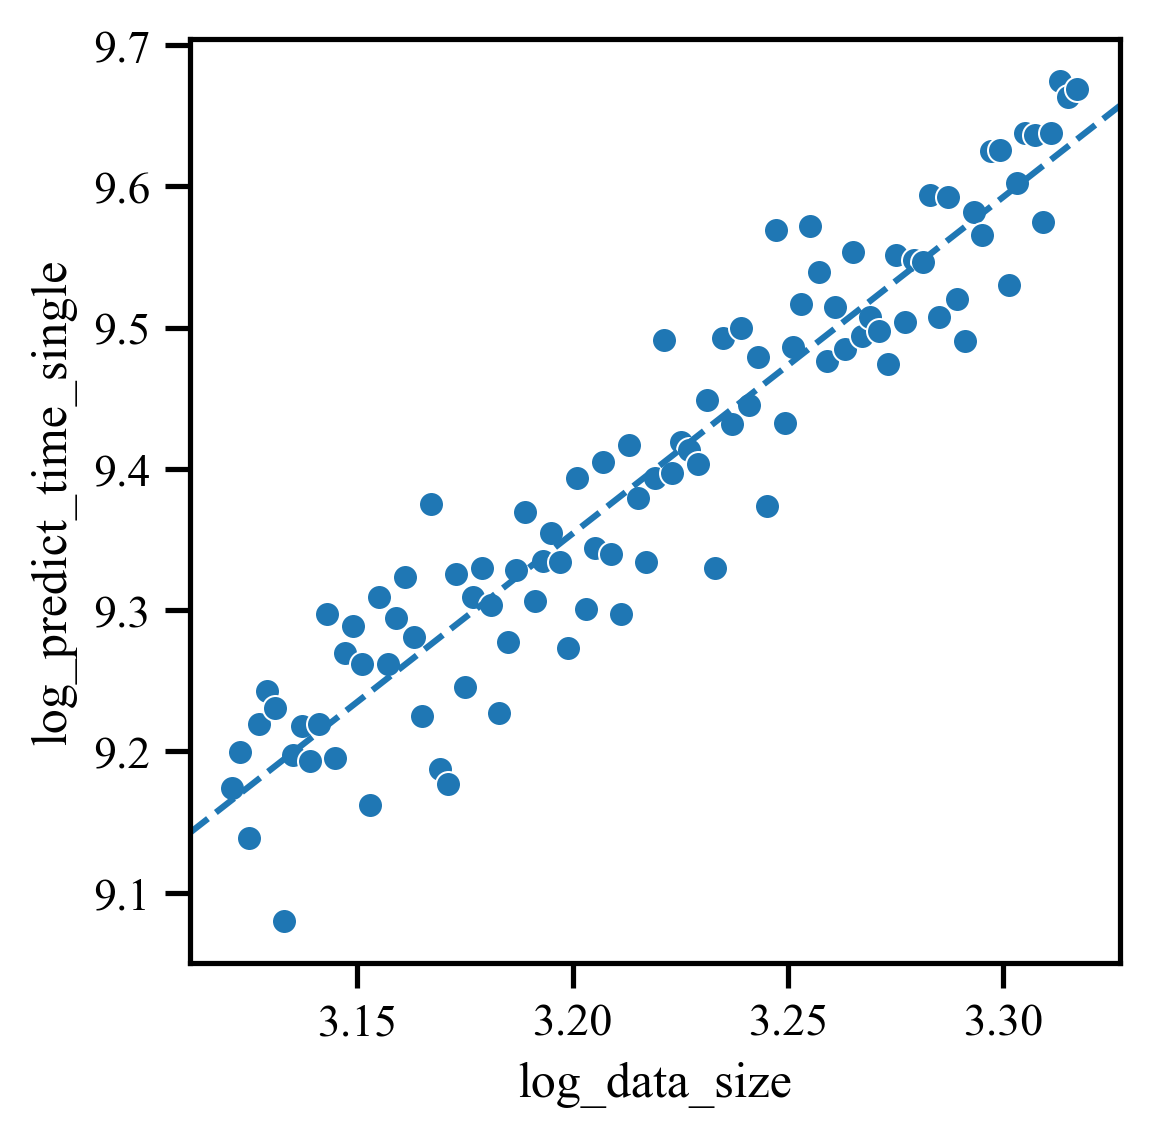

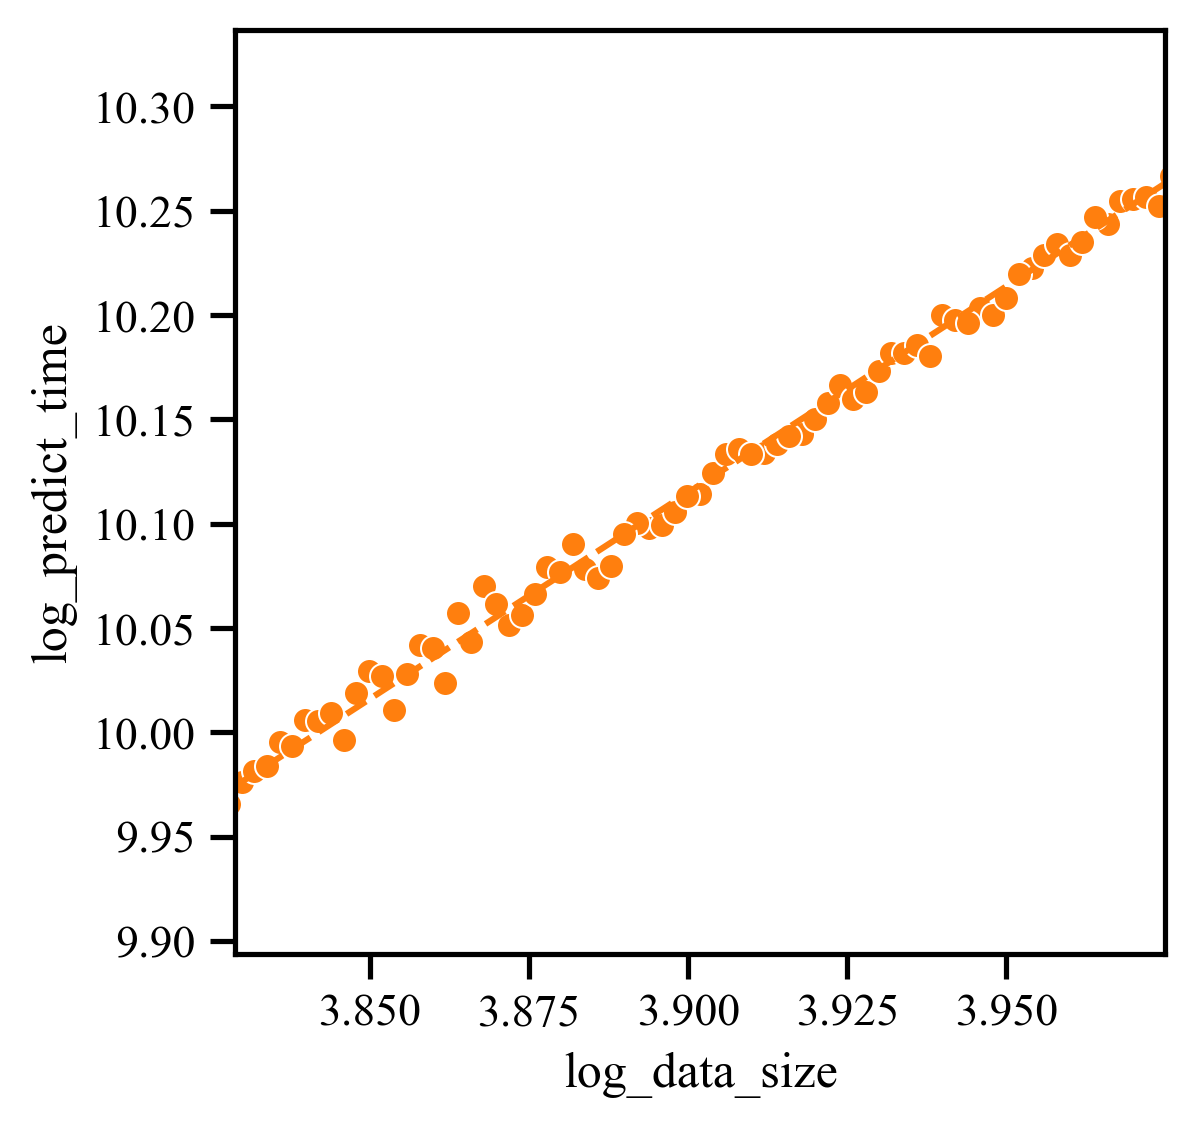

<Figure size 1920x1440 with 0 Axes>

In [10]:
last = 100
data_view = predict_data.copy()
figsize = (4, 4)

plt.figure(figsize=figsize)

ax, linreg_single = plot_empirical_complexity_log(
    data=data_view,
    x="log_data_size",
    y="log_predict_time_single",
    last=last,
    scatter_kwargs=dict(
        marker="o",
        color="C0",
    ),
    line_kwargs=dict(
        linestyle="--",
        color="C0",
    ),
)

aspect_ratio = np.diff(ax.get_xlim()) / np.diff(ax.get_ylim())

plt.figure(figsize=figsize)

ax2, linreg = plot_empirical_complexity_log(
    data=data_view,
    x="log_data_size",
    y="log_predict_time",
    last=last,
    scatter_kwargs=dict(
        marker="o",
        color="C1",
    ),
    line_kwargs=dict(
        linestyle="--",
        color="C1",
    ),
)

dx2 = np.diff(ax2.get_ylim()) * aspect_ratio / 2
xm = np.mean(ax2.get_xlim())

ax2.set_xlim(xm - dx2, xm + dx2)
plt.show()
plt.clf()

C:\Users\u0170502\AppData\Local\Temp\ipykernel_31984\1100113544.py:46: RuntimeWarning: invalid value encountered in power
  lambda x: 2**linreg.intercept * x**linreg.slope,


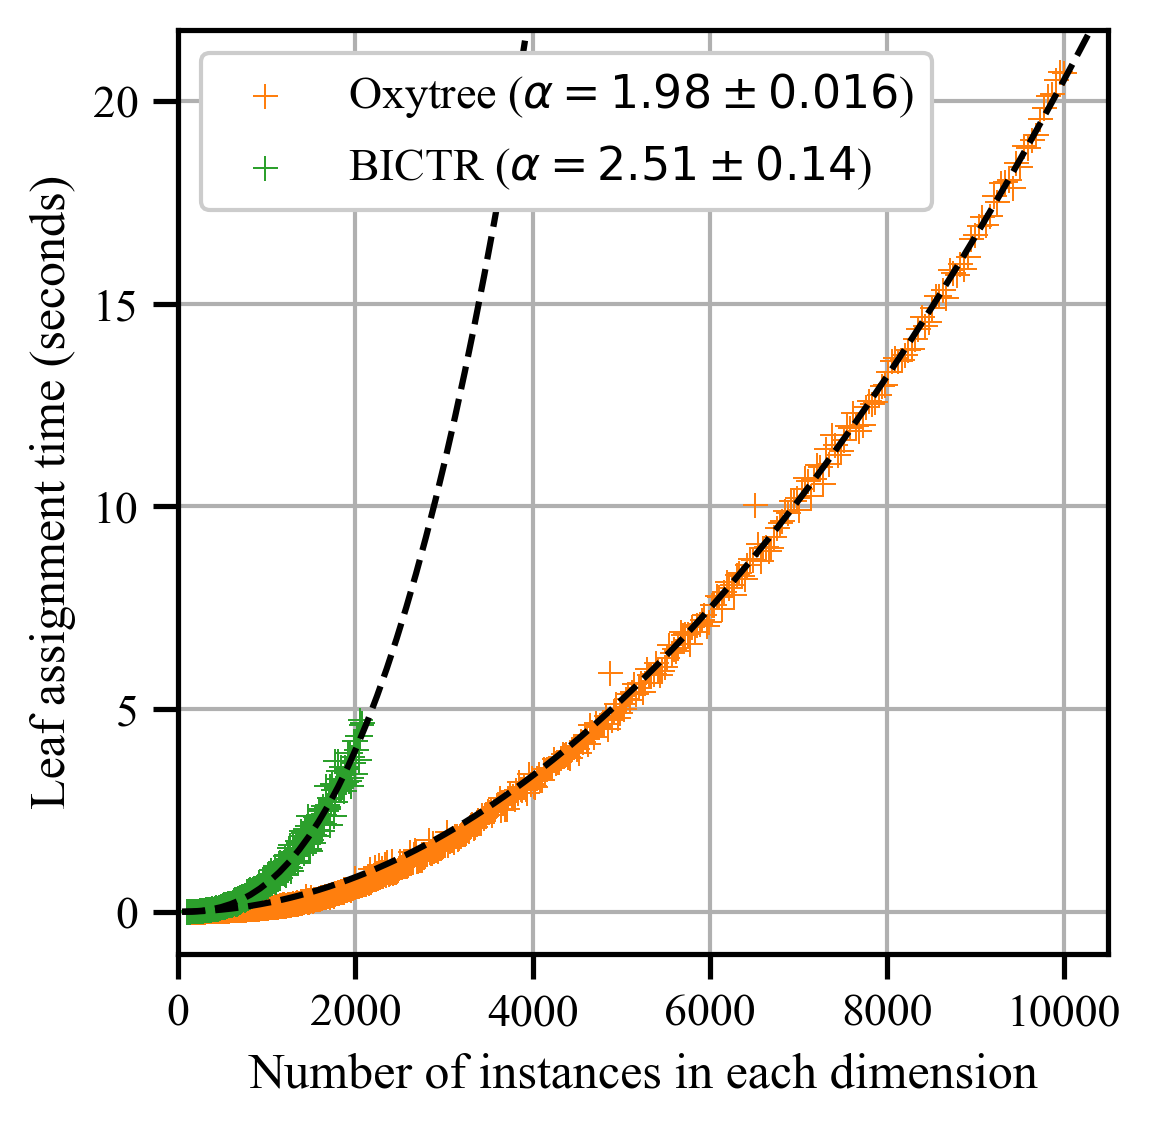

<Figure size 1920x1440 with 0 Axes>

In [11]:
last = .1
data_view = predict_data.copy()
figsize = (4, 4)

plt.figure(figsize=figsize)

ax = plt.gca()
lines = {}

for (col, name, color) in (
    ("predict_time", "Oxytree", "C1"),
    ("predict_time_single", "BICTR", "C2"),
):
    data = data_view.copy().dropna(subset=[col])
    if last <= 1:
        cutoff = data.data_size.quantile(1 - last)
        data_subset = data.loc[data.data_size > cutoff]
    else:
        data_subset = data.sort_values("data_size").iloc[-last:]

    linreg = stats.linregress(
        np.log2(data_subset.data_size.values),
        np.log2(data_subset[col].values),
        alternative="greater",
    )
    lines[col] = linreg

    ax = plot_empirical_complexity_linear(
        ax=ax,
        data=data,
        x="data_size",
        y=col,
        scatter_kwargs=dict(
            marker="+",
            color=color,
            # color="black",
            label=f"{name} ($\\alpha = {linreg.slope:.2f} \\pm {linreg.stderr:.2g}$)",
            zorder=2,
        ),
    )

ax.autoscale(enable=False)

for linreg in lines.values():
    plot_function(
        lambda x: 2**linreg.intercept * x**linreg.slope,
        kwargs=dict(color="black", linestyle="--", zorder=3),
    )

ax.set_xlim(0)

plt.ylabel("Leaf assignment time (seconds)")
plt.xlabel("Number of instances in each dimension")
plt.grid(zorder=1)
plt.legend(framealpha=1)

DIR_OUT.mkdir(parents=True, exist_ok=True)
plt.savefig(DIR_OUT / "empirical_complexity_leaf_assign.png", dpi=300, bbox_inches="tight", pad_inches=0.01)
plt.savefig(DIR_OUT / "empirical_complexity_leaf_assign.pdf", bbox_inches="tight", pad_inches=0.01)
with open(DIR_OUT / "empirical_complexity_leaf_assign.pickle", "wb") as f:
    pickle.dump(plt.gcf(), f)

plt.show()
plt.clf()

C:\Users\u0170502\AppData\Local\Temp\ipykernel_31984\779280794.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_view = data_view[fit_data.data_size < 8000]


Oxytree 3.099315372078994 0.05276132128633962
Oxytree[Deep] 3.0029609543536644 0.003809330293920376
BICTR 3.235636056711421 0.033468586735428074


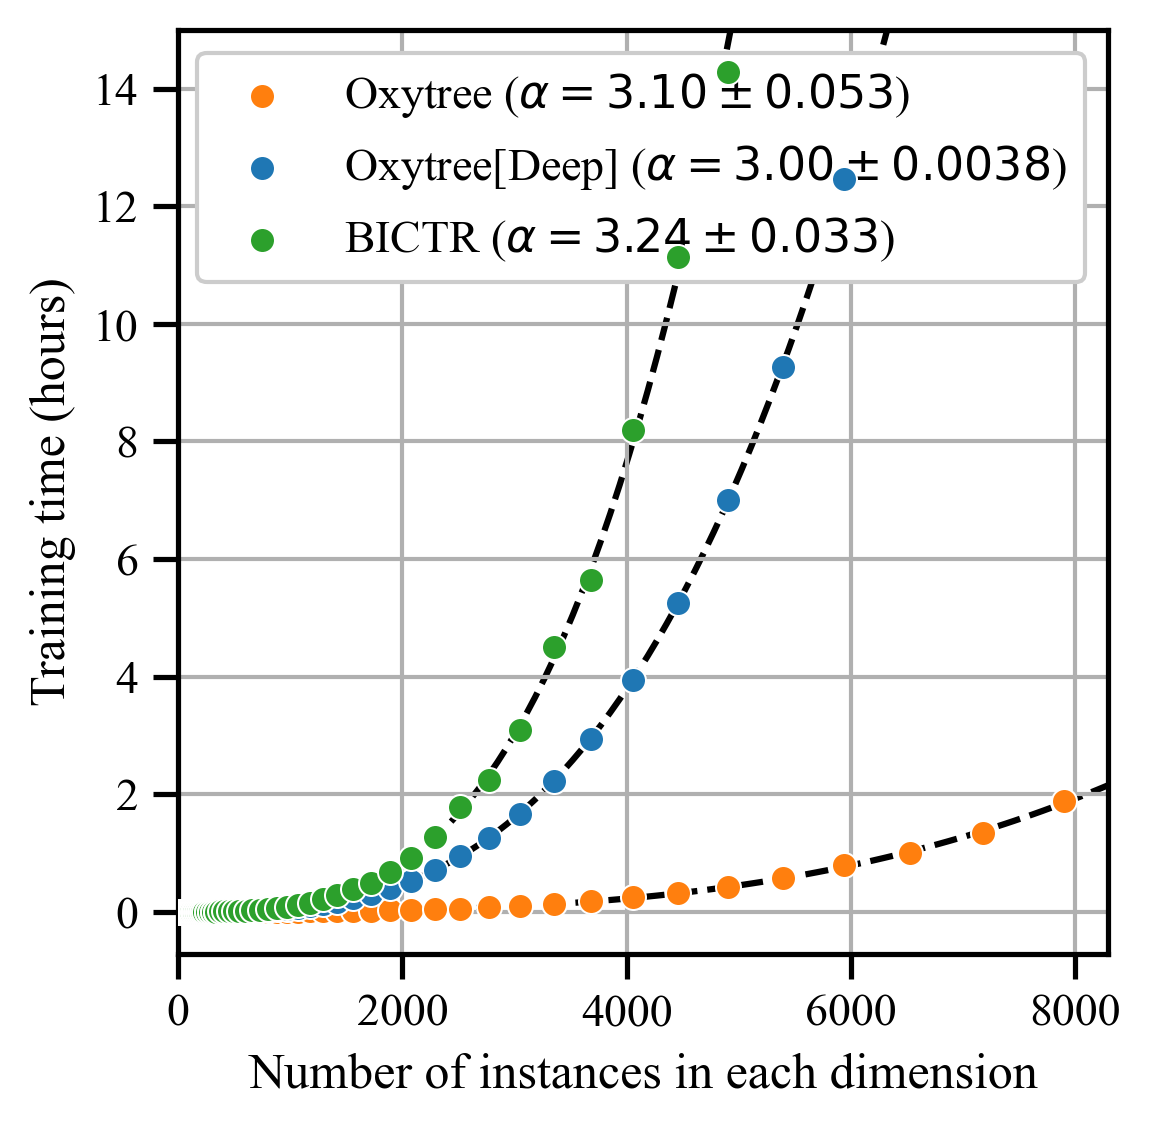

<Figure size 1920x1440 with 0 Axes>

In [12]:
last = 0.1
figsize = (4, 4)
data_view = fit_data.copy().sort_values("data_size")
data_view = data_view[fit_data.data_size < 8000]

plt.figure(figsize=figsize)
ax = plt.gca()

lines = []

# for estimator, estimator_data in data_view.groupby("estimator"):
for estimator, color in (
    ("Oxytree", "C1"),
    ("Oxytree[Deep]", "C0"),
    ("BICTR", "C2"),
):
    estimator_data = data_view.loc[data_view.estimator == estimator]
    estimator_data = estimator_data.copy().dropna(subset="fit_time")
    if last <= 1:
        cutoff = estimator_data.data_size.quantile(1 - last)
        data_subset = estimator_data.loc[estimator_data.data_size > cutoff]
    else:
        data_subset = estimator_data.sort_values("data_size").iloc[-last:]

    linreg = stats.linregress(
        np.log2(data_subset.data_size.values),
        np.log2(data_subset.fit_time.values),
        alternative="greater",
    )
    lines.append(linreg)  # Plot later

    print(estimator, linreg.slope, linreg.stderr)

    plot_empirical_complexity_linear(
        ax=ax,
        data=estimator_data,
        # linreg=linreg,
        x="data_size",
        y="fit_time",
        scatter_kwargs=dict(
            marker="o",
            color=color,
            label=f"{estimator} ($\\alpha = {linreg.slope:.2f} \\pm {linreg.stderr:.2g}$)",
            zorder=10,
        ),
        line_kwargs=dict(
            linestyle="--",
            color="black",
        ),
    )

ax.set_xlim(left=0)
ax.autoscale(enable=False)

for linreg in lines:
    plot_function(
        lambda x: 2**linreg.intercept * x**linreg.slope,
        kwargs=dict(color="black", linestyle="--", zorder=1),
    )

plt.ylabel("Training time (hours)")
plt.xlabel("Number of instances in each dimension")
plt.grid(zorder=0)
plt.legend(framealpha=1)

DIR_OUT.mkdir(parents=True, exist_ok=True)
plt.savefig(DIR_OUT / "empirical_complexity_fit.png", dpi=300, bbox_inches="tight", pad_inches=0.01)
plt.savefig(DIR_OUT / "empirical_complexity_fit.pdf", bbox_inches="tight", pad_inches=0.01)
with open(DIR_OUT / "empirical_complexity_fit.pickle", "wb") as f:
    pickle.dump(plt.gcf(), f)

plt.show()
plt.clf()

C:\Users\u0170502\AppData\Local\Temp\ipykernel_31984\749725338.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  data_view = data_view[fit_data.data_size < 8000]


Oxytree 2.1529057025980194 0.06912070174321251
Oxytree[Deep] 2.2776159254060486 0.16726563426950014
BICTR 2.4589752657857558 0.08550744840202865


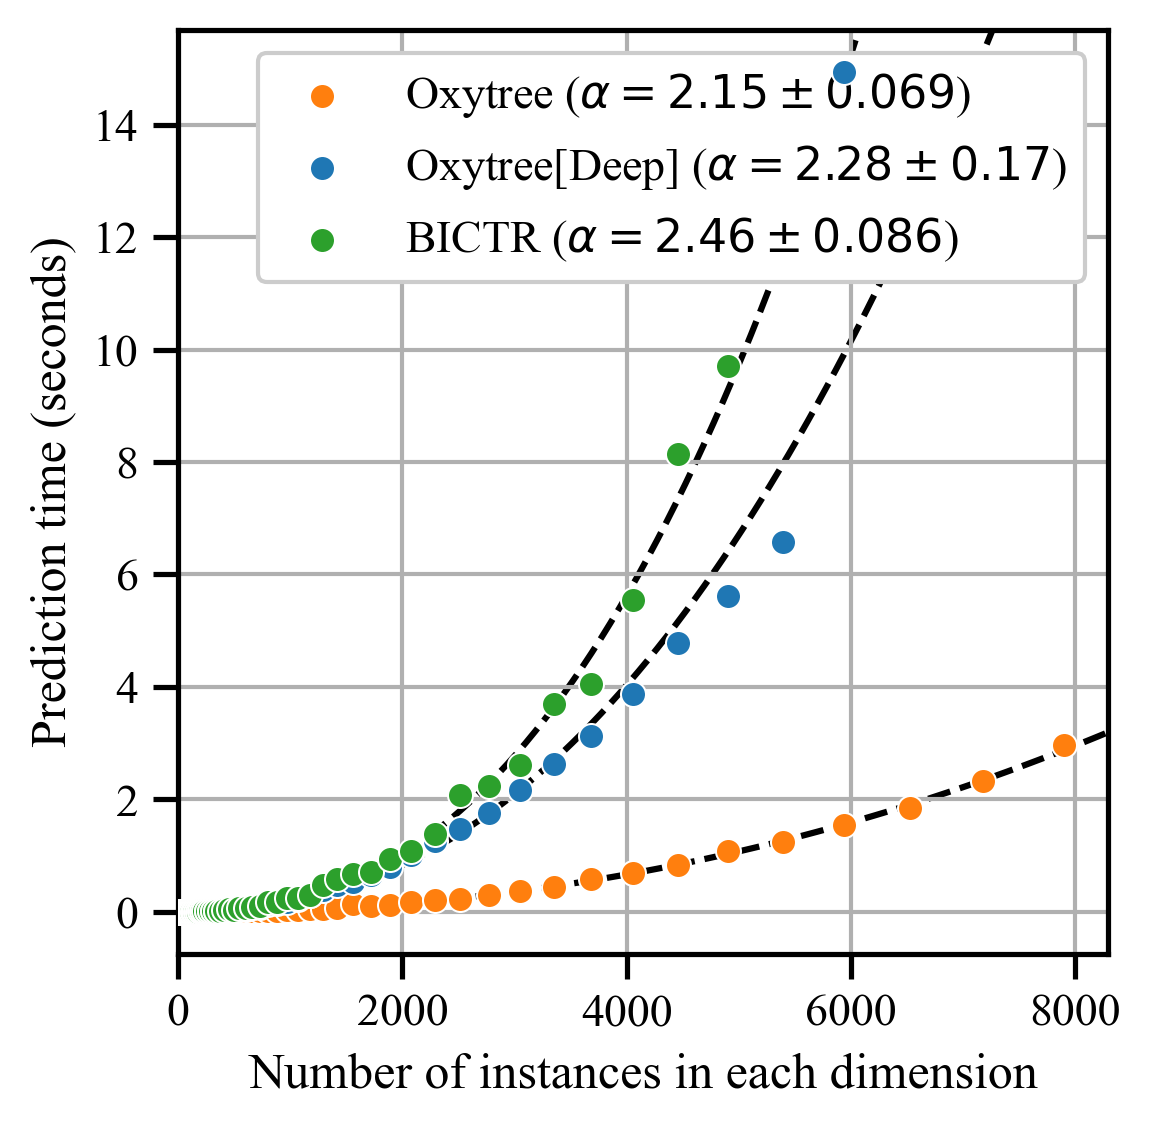

<Figure size 1920x1440 with 0 Axes>

In [13]:
last = 0.1
figsize = (4, 4)
data_view = fit_data.copy().sort_values("data_size")
data_view = data_view[fit_data.data_size < 8000]
data_view["predict_time"] *= 3600 # Convert to seconds

plt.figure(figsize=figsize)
ax = plt.gca()

lines = []

# for estimator, estimator_data in data_view.groupby("estimator"):
for estimator, color in (
    ("Oxytree", "C1"),
    ("Oxytree[Deep]", "C0"),
    ("BICTR", "C2"),
):
    estimator_data = data_view.loc[data_view.estimator == estimator]
    estimator_data = estimator_data.copy().dropna(subset="predict_time")
    if last <= 1:
        cutoff = estimator_data.data_size.quantile(1 - last)
        data_subset = estimator_data.loc[estimator_data.data_size > cutoff]
    else:
        data_subset = estimator_data.sort_values("data_size").iloc[-last:]

    linreg = stats.linregress(
        np.log2(data_subset.data_size.values),
        np.log2(data_subset.predict_time.values),
        alternative="greater",
    )
    lines.append(linreg)  # Plot later

    print(estimator, linreg.slope, linreg.stderr)

    plot_empirical_complexity_linear(
        ax=ax,
        data=estimator_data,
        # linreg=linreg,
        x="data_size",
        y="predict_time",
        scatter_kwargs=dict(
            marker="o",
            color=color,
            label=f"{estimator} ($\\alpha = {linreg.slope:.2f} \\pm {linreg.stderr:.2g}$)",
            zorder=10,
        ),
        line_kwargs=dict(
            linestyle="--",
            color="black",
        ),
    )

ax.set_xlim(left=0)
ax.autoscale(enable=False)

for linreg in lines:
    plot_function(
        lambda x: 2**linreg.intercept * x**linreg.slope,
        kwargs=dict(color="black", linestyle="--", zorder=1),
    )

plt.ylabel("Prediction time (seconds)")
plt.xlabel("Number of instances in each dimension")
plt.grid(zorder=0)
plt.legend(framealpha=1)

DIR_OUT.mkdir(parents=True, exist_ok=True)
plt.savefig(DIR_OUT / "empirical_complexity_predict.png", dpi=300, bbox_inches="tight", pad_inches=0.01)
plt.savefig(DIR_OUT / "empirical_complexity_predict.pdf", bbox_inches="tight", pad_inches=0.01)
with open(DIR_OUT / "empirical_complexity_predict.pickle", "wb") as f:
    pickle.dump(plt.gcf(), f)

plt.show()
plt.clf()

fit_time: 35.49 \pm 0.75 ($p = 3.924593974264197e-08$)


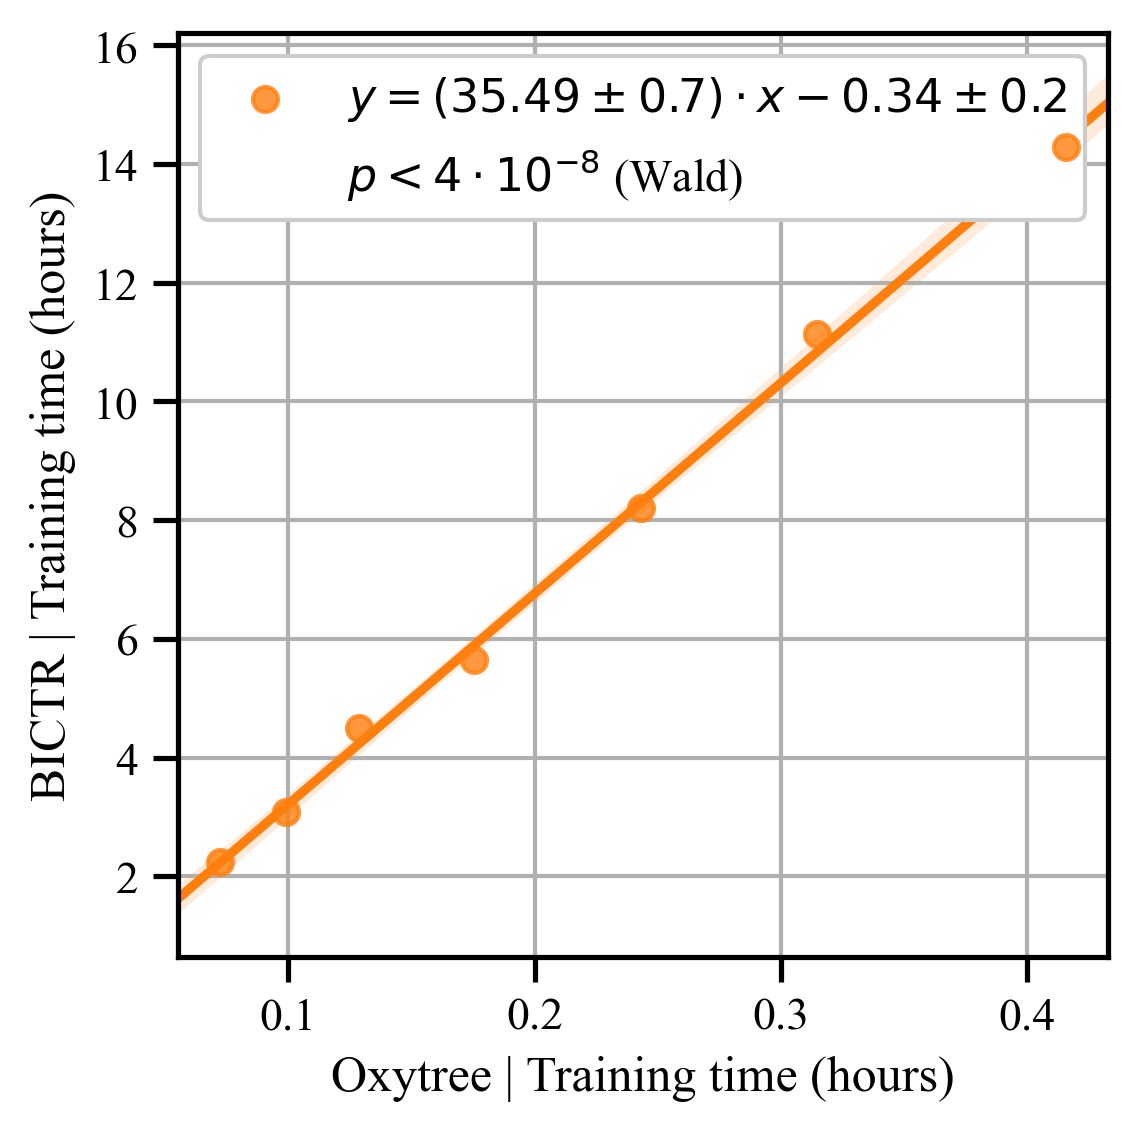

predict_time: 9.98 \pm 0.84 ($p = 3.7224185984284195e-05$)


<Figure size 1920x1440 with 0 Axes>

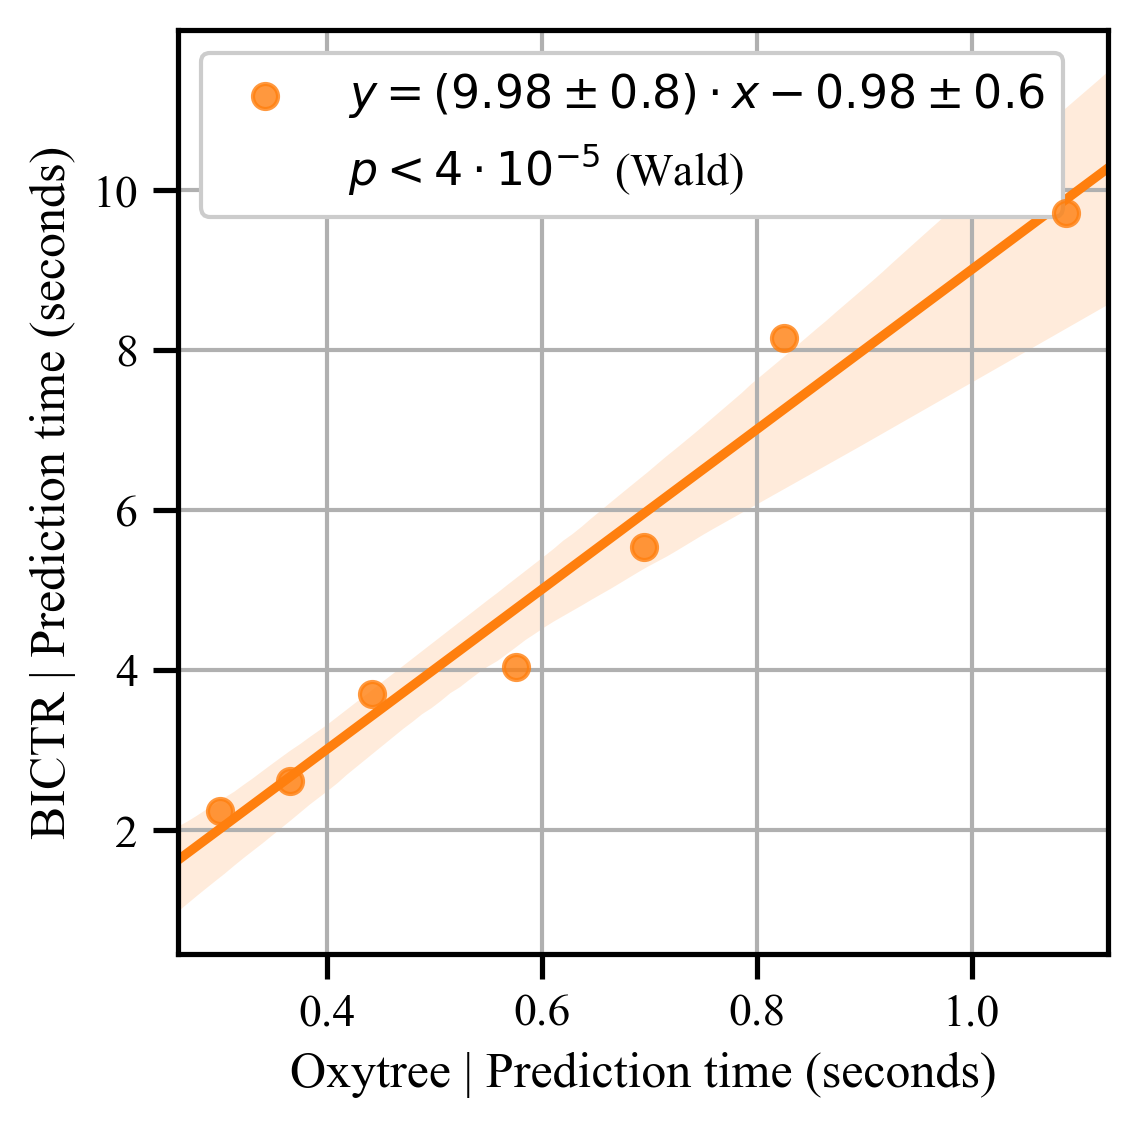

<Figure size 1920x1440 with 0 Axes>

In [14]:
estimators = ["Oxytree", "BICTR"]
data_view = fit_data.copy().loc[fit_data.estimator.isin(estimators)]
data_view["predict_time"] *= 60 * 60  # Convert to seconds



# display(data)


# display(data.drop_duplicates(subset=["estimator", "iteration"]))


for col, display_name in (
    ("fit_time", "Training time (hours)"),
    ("predict_time", "Prediction time (seconds)"),
):

    data = (
        data_view.groupby(["estimator", "data_size"])[col]
        .mean()
        .unstack("estimator")
        .dropna()
    )


    data = data.sort_index().iloc[-len(data) // 10 :]


    x = data[estimators[0]].values


    y = data[estimators[1]].loc[data[estimators[0]].index].values


    linreg = stats.linregress(x, y, alternative="greater")

    intercept_sign = "+" if linreg.intercept >= 0 else "-"
    plt.figure(figsize=(4, 4))


    plt.grid(zorder=0)


    ax = sns.regplot(
        data=data,

        x=estimators[0],
        y=estimators[1],
        label=(
            f"$y=({linreg.slope:.2f} \\pm {linreg.stderr:.1g})\\cdot x"
            f" {intercept_sign} {abs(linreg.intercept):.2f}"
            f" \\pm {linreg.intercept_stderr:.1g}$"
        ),
        marker="o",
        color="C1",
        truncate=False,
        scatter_kws=dict(
            zorder=20,
        ),
    )
    plt.xlabel(f"{estimators[0]} | {display_name}")
    plt.ylabel(f"{estimators[1]} | {display_name}")
    plt.plot([], [], " ", label=f"${format_p_value(linreg.pvalue)}$ (Wald)")
    plt.legend(framealpha=1)

    path_out = DIR_OUT / f"{col}_{estimators[0]}_{estimators[1]}.pdf"
    print(f"{col}: {linreg.slope:.2f} \\pm {linreg.stderr:.2g} ($p = {linreg.pvalue}$)")
    plt.savefig(path_out, bbox_inches="tight", pad_inches=0.01)
    plt.savefig(
        path_out.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.01
    )
    plt.show()
    plt.clf()